In [5]:
import matplotlib.pyplot as plt


In [2]:
# step 1 - Load data
import pandas as pd

df = pd.read_csv('customer_data.csv', encoding='latin1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Step 2: Quick data exploration
print(df.head())
print(df.info())
print(df.describe())
print(df.dtypes)
print("Missing values:\n", df.isnull().sum())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

       InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 8:26       2.55     17850.0  United Kingdom  
1  01-12-2010 8:26       3.39     17850.0  United Kingdom  
2  01-12-2010 8:26       2.75     17850.0  United Kingdom  
3  01-12-2010 8:26       3.39     17850.0  United Kingdom  
4  01-12-2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoic

In [5]:
# Step 3: Drop rows with missing CustomerID or Quantity/UnitPrice
df = df.dropna(subset=['CustomerID', 'Quantity', 'UnitPrice'])

In [6]:
# Step 4: Remove duplicates
df = df.drop_duplicates()

In [7]:
# Step 5: Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


In [12]:
# Step 6: Aggregate total spending per customer
customer_spending = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()

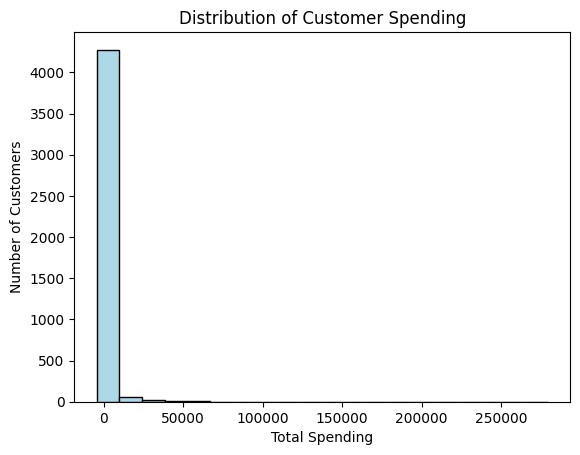

In [58]:
# Step 7: Plot distribution of customer spending
plt.hist(customer_spending ['TotalAmount'], bins=20, color='lightblue', edgecolor='black')
plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
# Step 8: Create Spending Score and Segmentation

# Step 8.1: Normalize total spending to a score (0–100)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))
customer_spending['SpendingScore'] = scaler.fit_transform(customer_spending[['TotalAmount']])

In [32]:
# Step 8.2: Segment customers
# You can use simple rules based on score
def segment(score):
    if score < 33:
        return 'Low'
    elif score < 66:
        return 'Medium'
    else:
        return 'High'

customer_spending['Segment'] = customer_spending['SpendingScore'].apply(segment)

In [33]:
# Step 8.3: Check results
print(customer_spending.head())


   CustomerID  TotalAmount  SpendingScore Segment
0     12346.0         0.00       1.510917     Low
1     12347.0      4310.00       3.029717     Low
2     12348.0      1797.24       2.144246     Low
3     12349.0      1757.55       2.130260     Low
4     12350.0       334.40       1.628756     Low


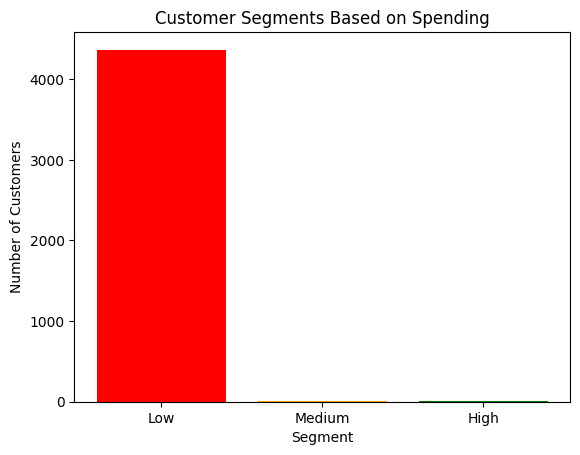

In [59]:
# Step 8.4: Visualize segments
segment_counts = customer_spending['Segment'].value_counts()
plt.bar(segment_counts.index, segment_counts.values, color=['red', 'orange', 'green'])
plt.title('Customer Segments Based on Spending')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


In [35]:
# Step 9: Detect outliers in customer spending
Q1 = customer_spending['TotalAmount'].quantile(0.25)
Q3 = customer_spending['TotalAmount'].quantile(0.75)
IQR = Q3 - Q1

In [36]:
# Identify outliers
outliers = customer_spending[
    (customer_spending['TotalAmount'] < (Q1 - 1.5 * IQR)) |
    (customer_spending['TotalAmount'] > (Q3 + 1.5 * IQR))
]

print("Number of outliers:", outliers.shape[0])
print(outliers.head())

Number of outliers: 421
    CustomerID  TotalAmount  SpendingScore Segment
1      12347.0      4310.00       3.029717     Low
10     12357.0      6207.67       3.698437     Low
12     12359.0      6182.98       3.689736     Low
15     12362.0      5154.58       3.327339     Low
27     12378.0      4008.62       2.923514     Low


In [37]:
# (Optional) Remove outliers for smoother visualization
customer_spending_clean = customer_spending[
    (customer_spending['TotalAmount'] >= (Q1 - 1.5 * IQR)) &
    (customer_spending['TotalAmount'] <= (Q3 + 1.5 * IQR))
]

C:\Users\ajaym\AppData\Local\Temp\ipykernel_21308\373379624.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([customer_spending_clean['TotalAmount'], outliers['TotalAmount']],


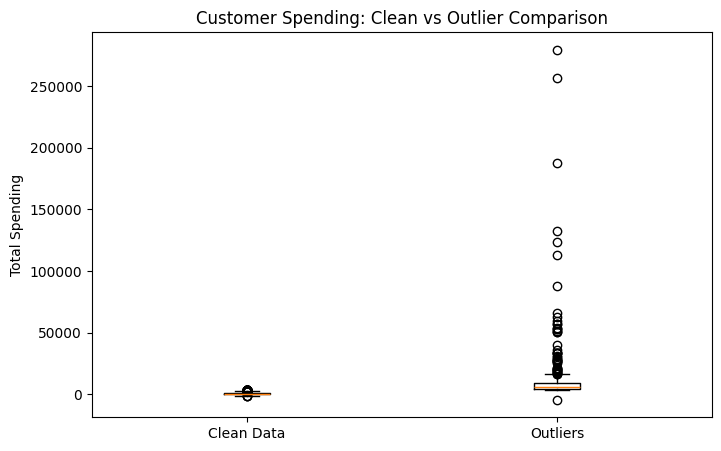

In [60]:
# Visualize clean vs outlier spending
plt.figure(figsize=(8,5))
plt.boxplot([customer_spending_clean['TotalAmount'], outliers['TotalAmount']],
            labels=['Clean Data', 'Outliers'])
plt.title('Customer Spending: Clean vs Outlier Comparison')
plt.ylabel('Total Spending')
plt.show()

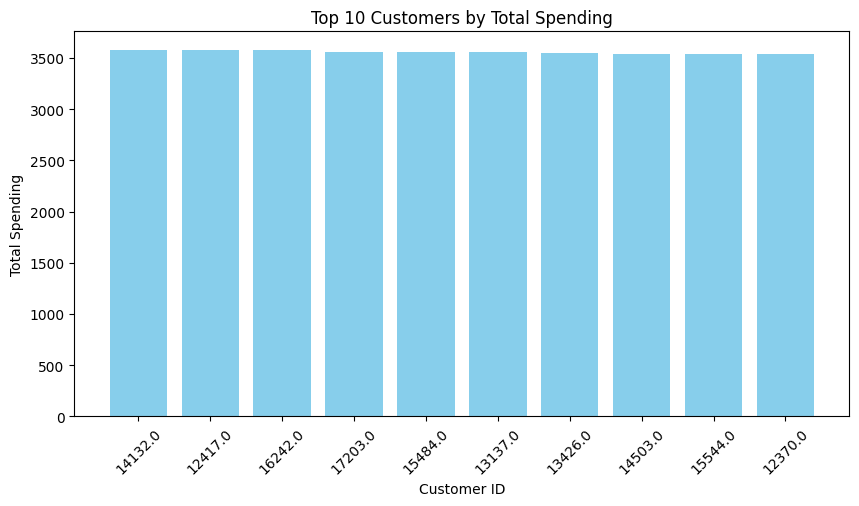

In [61]:
# Step 10.1: Top 10 Customers by Total Spending
top_customers = customer_spending_clean.sort_values('TotalAmount', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_customers['CustomerID'].astype(str), top_customers['TotalAmount'], color='skyblue')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

In [40]:
# Ensure TotalAmount exists
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


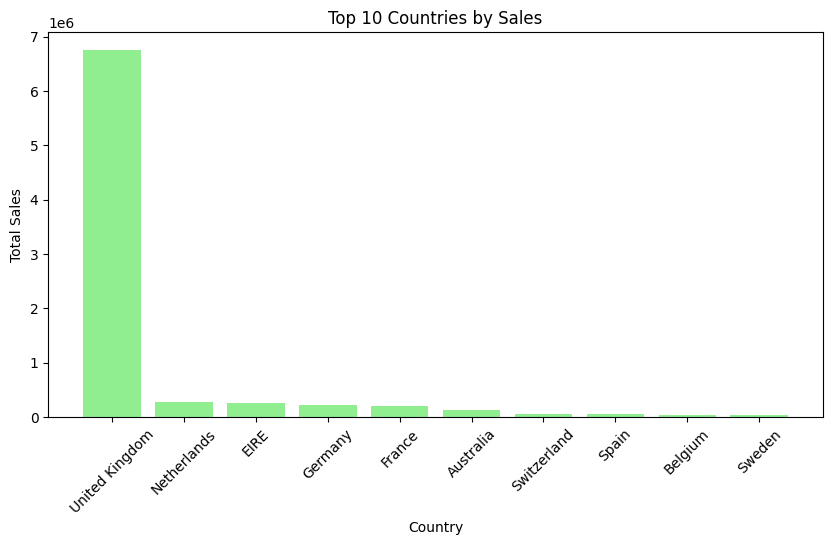

In [62]:
# Step 10.2: Top 10 Selling Countries
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
top_countries = country_sales.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values, color='lightgreen')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [42]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')


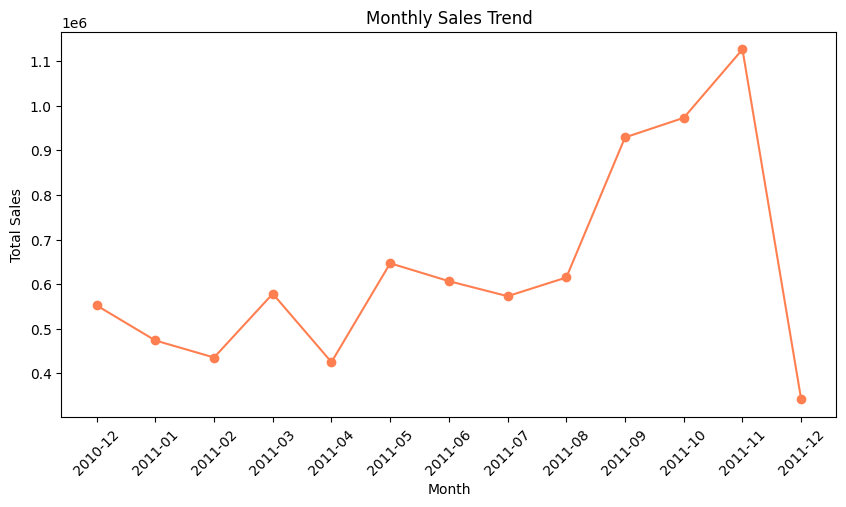

In [63]:
# step 10.3 : Sales Trend Over Time
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'].astype(str), monthly_sales['TotalAmount'], marker='o', color='coral')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [64]:
Step 11: Customer Segmentation (RFM Analysis)

SyntaxError: invalid syntax (1596740680.py, line 1)

In [45]:
import datetime as dt

# Find the most recent date in the dataset
latest_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [46]:
# RFM Calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).reset_index()

In [47]:
# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [48]:
Step 11.2 — Visualize RFM Distributions

SyntaxError: invalid character '—' (U+2014) (626914303.py, line 1)

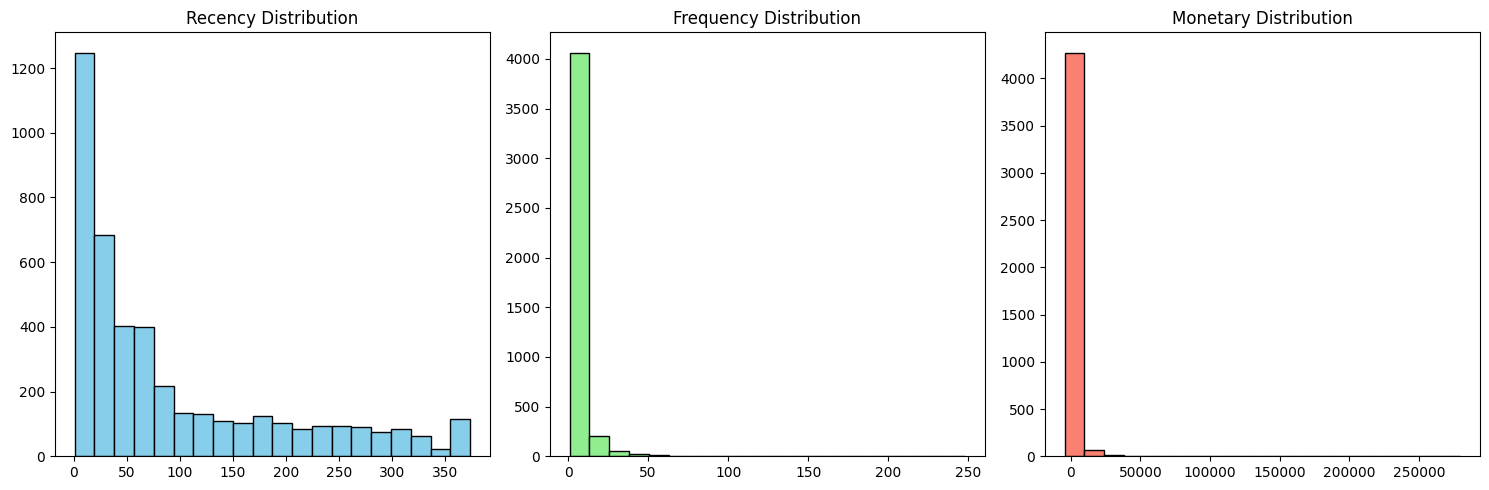

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(rfm['Recency'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Recency Distribution')

axes[1].hist(rfm['Frequency'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Frequency Distribution')

axes[2].hist(rfm['Monetary'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [50]:
Step 11.3 — Classify Customers (Optional, but Powerful)

SyntaxError: invalid character '—' (U+2014) (2004996592.py, line 1)

In [51]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,326,2,0.00,1,2,1,121,4
1,12347.0,2,7,4310.00,5,4,5,545,14
2,12348.0,75,4,1797.24,2,3,4,234,9
3,12349.0,19,1,1757.55,4,1,4,414,9
4,12350.0,310,1,334.40,1,1,2,112,4


In [52]:
Step 12: Customer Segmentation from RFM

SyntaxError: invalid syntax (2697017462.py, line 1)

In [53]:

# Step 12.1 - Create RFM Score Segments

# Create an overall RFM score
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Define segments based on total RFM score
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalist'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['CustomerSegment'] = rfm['RFM_Score'].apply(segment_customer)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,CustomerSegment
0,12346.0,326,2,0.00,1,2,1,121,4,Lost Customers
1,12347.0,2,7,4310.00,5,4,5,545,14,Champions
2,12348.0,75,4,1797.24,2,3,4,234,9,Potential Loyalist
3,12349.0,19,1,1757.55,4,1,4,414,9,Potential Loyalist
4,12350.0,310,1,334.40,1,1,2,112,4,Lost Customers


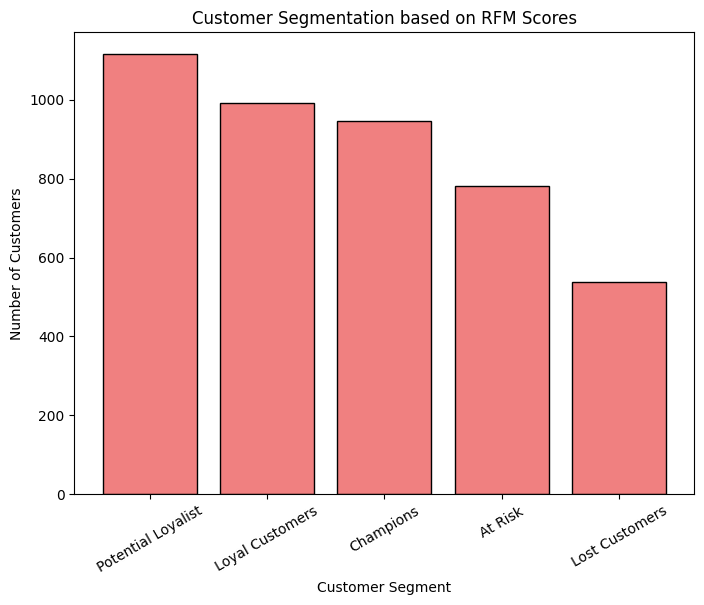

In [54]:
# Step 12.2 - Visualize Customer Segments
import matplotlib.pyplot as plt

segment_counts = rfm['CustomerSegment'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(segment_counts.index, segment_counts.values, color='lightcoral', edgecolor='black')
plt.title('Customer Segmentation based on RFM Scores')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

In [55]:
# Export the RFM table with segments
rfm.to_csv("customer_rfm_segments.csv", index=False)
print("RFM Segmented data exported successfully!")


RFM Segmented data exported successfully!


In [56]:
# Export the transaction-level dataset with TotalAmount
df.to_csv("cleaned_customer_data.csv", index=False)
print("Cleaned transaction-level data exported successfully!")


Cleaned transaction-level data exported successfully!


In [57]:
# Export transaction-level data (with TotalAmount)
df.to_csv("cleaned_customer_data.csv", index=False)

# Export customer-level RFM & segments
rfm.to_csv("customer_rfm_segments.csv", index=False)

print("CSV files exported successfully!")


CSV files exported successfully!
